# Assignment 2 2AMM10 2023-2024

## Group: DL group 42
### Member 1: Dan Wu (2176963)
### Member 2: Anh Nguyên (1612131)
### Member 3: Hrvoje Miljak (1753517)

We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [1]:
%pip show torch

Name: torch
Version: 2.7.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /home/mil/anaconda3/envs/2AMM10/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: torchaudio, torchvision
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install rdkit
%pip install torch_geometric
%pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.7.0+cu128.html

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in links: https://data.pyg.org/whl/torch-2.7.0+cu128.html
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, rdchem
from rdkit import RDLogger
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool
from sklearn.metrics import mean_squared_error, r2_score
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt
import random

/home/mil/anaconda3/envs/2AMM10/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [5]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [6]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


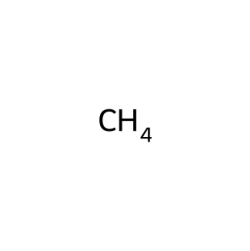

In [7]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.007│     1.371│     0.156
  O  │  8   │     0.134│    -0.026│     0.033
  C  │  6   │     0.722│    -0.543│    -1.168
  C  │  6   │    -0.139│    -0.203│    -2.396
  C  │  6   │     2.165│    -0.044│    -1.347
  C  │  6   │     0.736│    -2.060│    -0.974
  C  │  6   │     0.981│    -2.671│     0.352
  N  │  7   │    -0.359│    -2.735│    -0.270
  H  │  1   │     0.958│     1.896│     0.126
  H  │  1   │    -0.660│     1.800│    -0.614
  H  │  1   │    -0.464│     1.549│     1.133
  H  │  1   │    -0.142│     0.870│    -2.609
  H  │  1   │     0.254│    -0.711│    -3.282
  H  │  1   │    -1.169│    -0.534│    -2.242
  H  │  1   │     2.741│    -0.217│    -0.434
  H  │  1   │     2.650│    -0.585│    -2.165
  H  │  1   │     2.204│     1.021│    -1.592
  H  │  1   │     1.081│    -2.591│    -1.860
  H  │  1   │     1.502│    -3.622│     0.423
  H  │  1   │     1.116│    -2.000

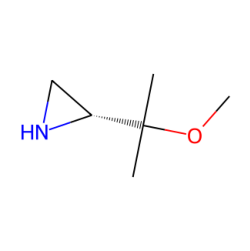

In [8]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train = False

## Task 1

SMILES

In [10]:
# SMILES Dataset generation

class SMILESDataset(InMemoryDataset):
    def __init__(self, smiles, formation_energies):
        self.smiles = smiles
        self.formation_energies = formation_energies
        super(SMILESDataset, self).__init__('.')
        self.data, self.slices = self.collate([
            create_smiles_data(smile, formation_energy) for smile, formation_energy in zip(smiles, formation_energies)
        ])

def create_smiles_data(smile, formation_energy):
    mol = Chem.MolFromSmiles(smile)

    # Nodes are the atoms
    atom_features = [get_atom_features(atom) for atom in mol.GetAtoms()]
    node_features = torch.stack(atom_features, dim=0)
    
    # Edges are the bonds
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        edge_index.append([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
        edge_index.append([bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()])

        bond_features = get_bond_features(bond)
        edge_attr.append(bond_features)
        edge_attr.append(bond_features)
    
    if len(edge_attr) == 0:
        edge_attr = torch.empty((0, 30), dtype=torch.float)
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_attr, dim=0)

    target = torch.tensor([formation_energy], dtype=torch.float)

    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=target)

def get_atom_features(atom):
    # 118 Atomic number
    atomic_number = atom.GetAtomicNum()
    one_hot_atomic = torch.zeros(118, dtype=torch.float)
    one_hot_atomic[atomic_number-1] = 1

    # 6 Degree
    degree = atom.GetDegree()
    one_hot_degree = torch.zeros(6, dtype=torch.float)
    one_hot_degree[min(degree, 5)] = 1

    # 1 Formal charge
    formal_charge = torch.tensor([max(-2, min(atom.GetFormalCharge(), 2))], dtype=torch.float)

    # 1 Aromatic
    aromatic = torch.tensor([int(atom.GetIsAromatic())], dtype=torch.float)

    # 5 Total Num Hs
    total_hs = atom.GetTotalNumHs()
    one_hot_total_hs = torch.zeros(5, dtype=torch.float)
    one_hot_total_hs[min(total_hs, 4)] = 1

    # 5 Hybridization
    hybridizations = [
        rdchem.HybridizationType.SP,
        rdchem.HybridizationType.SP2,
        rdchem.HybridizationType.SP3,
        rdchem.HybridizationType.SP3D,
        rdchem.HybridizationType.SP3D2
    ]
    hybrid = atom.GetHybridization()
    one_hot_hybrid = torch.zeros(len(hybridizations), dtype=torch.float)
    if hybrid in hybridizations:
        one_hot_hybrid[hybridizations.index(hybrid)] = 1

    # 3 Chirality
    chirality = atom.GetChiralTag()
    one_hot_chiral = torch.zeros(3, dtype=torch.float)
    if chirality == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW:
        one_hot_chiral[0] = 1
    elif chirality == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW:
        one_hot_chiral[1] = 1
    else:
        one_hot_chiral[2] = 1 

    # 139 total
    return torch.cat([one_hot_atomic, one_hot_degree, formal_charge, aromatic, one_hot_total_hs, one_hot_hybrid, one_hot_chiral])

def get_bond_features(bond):
    # 22 Bond types
    bond_types = [
        rdchem.BondType.UNSPECIFIED,
        rdchem.BondType.SINGLE,
        rdchem.BondType.DOUBLE,
        rdchem.BondType.TRIPLE,
        rdchem.BondType.QUADRUPLE,
        rdchem.BondType.QUINTUPLE,
        rdchem.BondType.HEXTUPLE,
        rdchem.BondType.ONEANDAHALF,
        rdchem.BondType.TWOANDAHALF,
        rdchem.BondType.THREEANDAHALF,
        rdchem.BondType.FOURANDAHALF,
        rdchem.BondType.FIVEANDAHALF,
        rdchem.BondType.AROMATIC,
        rdchem.BondType.IONIC,
        rdchem.BondType.HYDROGEN,
        rdchem.BondType.THREECENTER,
        rdchem.BondType.DATIVEONE,
        rdchem.BondType.DATIVE,
        rdchem.BondType.DATIVEL,
        rdchem.BondType.DATIVER,
        rdchem.BondType.OTHER,
        rdchem.BondType.ZERO
    ]
    bond_type = bond.GetBondType()
    one_hot_bond_type = torch.zeros(22, dtype=torch.float)
    if bond_type in bond_types:
        index = bond_types.index(bond_type)
        one_hot_bond_type[index] = 1

    # 1 Conjugated
    is_conjugated = torch.tensor([int(bond.GetIsConjugated())], dtype=torch.float)

    # 1 Ring
    is_in_ring = torch.tensor([int(bond.IsInRing())], dtype=torch.float)

    # 6 Stereo types
    stereo_types = [
        rdchem.BondStereo.STEREONONE,
        rdchem.BondStereo.STEREOANY,
        rdchem.BondStereo.STEREOZ,
        rdchem.BondStereo.STEREOE,
        rdchem.BondStereo.STEREOCIS,
        rdchem.BondStereo.STEREOTRANS,
    ]
    stereo = bond.GetStereo()
    one_hot_stereo = torch.zeros(len(stereo_types), dtype=torch.float)
    if stereo in stereo_types:
        one_hot_stereo[stereo_types.index(stereo)] = 1

    # 30 Total
    return torch.cat([one_hot_bond_type, is_conjugated, is_in_ring, one_hot_stereo])

smiles_train = [smiles_data[i] for i in train_idxes]
formation_energies_train = [fe[i] for i in train_idxes]

smiles_test = [smiles_data[i] for i in test_idxes]
formation_energies_test = [fe[i] for i in test_idxes]

train_smiles_data = SMILESDataset(smiles_train, formation_energies_train)
test_smiles_data = SMILESDataset(smiles_test, formation_energies_test)

smiles_train_loader = DataLoader(train_smiles_data, batch_size=32, shuffle=True)
smiles_test_loader = DataLoader(test_smiles_data, batch_size=32, shuffle=False)

In [11]:
# SMILES GNN

class SmilesGNN(torch.nn.Module):
    def __init__(self, hidden_dim, node_dim, edge_dim):
        super(SmilesGNN, self).__init__()

        input = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv1 = GINEConv(input, edge_dim=edge_dim)
        self.norm1 = nn.BatchNorm1d(hidden_dim)
        
        seq = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv2 = GINEConv(seq, edge_dim=edge_dim)
        self.norm2 = nn.BatchNorm1d(hidden_dim)

        seq2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv3 = GINEConv(seq2, edge_dim=edge_dim)
        self.norm3 = nn.BatchNorm1d(hidden_dim)

        self.dropout = nn.Dropout(p=0.2)
        self.lin = nn.Linear(hidden_dim, 1)
        
    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_feature = data.edge_attr
        batch = data.batch

        x = self.conv1(x, edge_index, edge_feature)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index, edge_feature)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index, edge_feature)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze()

In [12]:
# Smiles training and testing 

def smilesTrain(model, loader, lossfn, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = lossfn(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def smilesTest(model, loader, lossfn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = lossfn(out, batch.y.squeeze())
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

In [13]:
smilesModel = SmilesGNN(hidden_dim=128, node_dim=139, edge_dim=30).to(device)
optimizer = torch.optim.Adam(smilesModel.parameters(), lr=0.0001)
mseLoss = nn.MSELoss()

if train:
    for epoch in range(1, 51):
        train_loss = smilesTrain(smilesModel, smiles_train_loader, mseLoss, optimizer)
        test_loss = smilesTest(smilesModel, smiles_test_loader, mseLoss)
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    torch.save(smilesModel.state_dict(), 'SMILES_model.pth')

In [14]:
# Load model from file

smilesModel = SmilesGNN(hidden_dim=128, node_dim=139, edge_dim=30).to(device)
smilesModel.load_state_dict(torch.load('SMILES_model.pth'))
smilesModel.eval()

SmilesGNN(
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=139, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (norm3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (lin): Linear(in_features=128, out_features=1, bias=True)
)

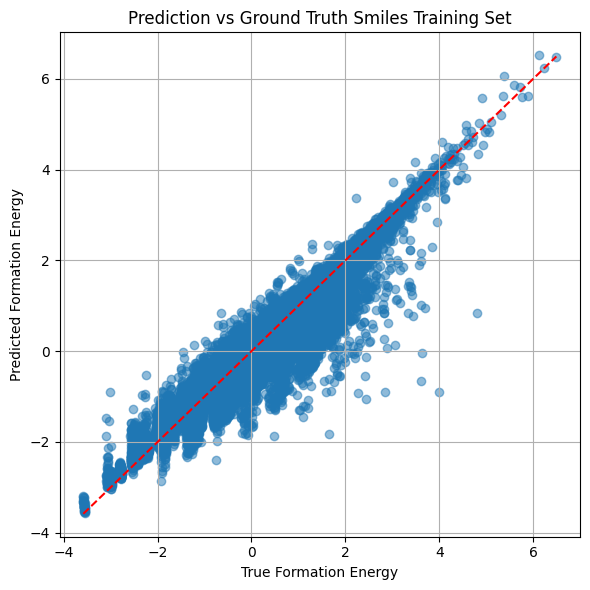

R² Score: 0.9425


In [47]:
# Show predictions vs ground truth for SMILES training set

y_true = []
y_pred = []

with torch.no_grad():
    for batch in smiles_train_loader:
        batch = batch.to(device)
        output = smilesModel(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(output.cpu().numpy())

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True Formation Energy")
plt.ylabel("Predicted Formation Energy")
plt.title("Prediction vs Ground Truth Smiles Training Set")
plt.grid(True)
plt.tight_layout()
plt.show()

r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}")

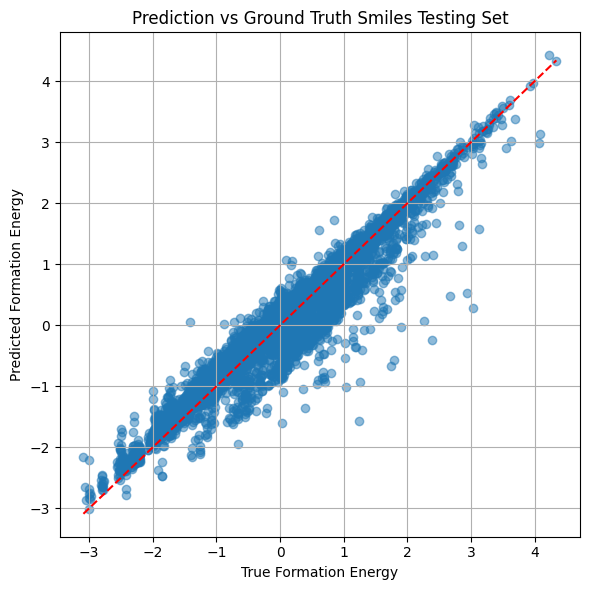

R² Score: 0.9380


In [48]:
# Show predictions vs ground truth for SMILES testing set

y_true = []
y_pred = []

with torch.no_grad():
    for batch in smiles_test_loader:
        batch = batch.to(device)
        output = smilesModel(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(output.cpu().numpy())

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True Formation Energy")
plt.ylabel("Predicted Formation Energy")
plt.title("Prediction vs Ground Truth Smiles Testing Set")
plt.grid(True)
plt.tight_layout()
plt.show()

r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}")

GEOMETRIC

In [16]:
# Geometric dataset generation

def create_graph_data(pos, typ, fe):
    # Convert to tensor
    pos_tensor = torch.tensor(pos, dtype=torch.float)
    type_tensor = torch.tensor(typ, dtype=torch.long)
    fe_tensor = torch.tensor(fe*std + mu, dtype=torch.float)

    # Create edge index
    num_atoms = len(pos)
    edge_index = []
    for i in range(num_atoms):
        for j in range(num_atoms):
            if i != j:
                edge_index.append([i, j])    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x=type_tensor.unsqueeze(1).float()
    
    # Compute edge attributes (e.g., distances)
    row, col = edge_index
    edge_vec = pos_tensor[row] - pos_tensor[col]
    edge_attr = torch.norm(edge_vec, dim=1, keepdim=True)

    data = Data(x, pos=pos_tensor, edge_index=edge_index, edge_attr=edge_attr, y=fe_tensor)
    return data

# Create graph data for training and testing
train_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in train_idxes]
test_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in test_idxes]

# Create validation set from 10% of training data
val_size = int(0.1 * len(train_graph_data))
train_graph_data, val_graph_data = train_graph_data[:-val_size], train_graph_data[-val_size:]

# Create DataLoader for training and testing
graph_train_loader = DataLoader(train_graph_data, batch_size=128, shuffle=True)
graph_val_loader = DataLoader(val_graph_data, batch_size=128, shuffle=False)
graph_test_loader = DataLoader(test_graph_data, batch_size=128, shuffle=False)

In [ ]:
# Geometric GNN
class Node_Embedding(nn.Module):
    def __init__ (self, node_feature_dim, node_embedding_dim):
        super(Node_Embedding, self).__init__()
        self.embedding_dim = node_embedding_dim
        self.feature_dim = node_feature_dim
        self.embedding = nn.Linear(node_feature_dim, node_embedding_dim)
    def forward(self, nodes):
        assert nodes.size(-1) == self.feature_dim, 'wrong input dimension of node features!'
        out = self.embedding(nodes)
        return out
    
# Message Passing Layer
class MP_layer(nn.Module):
    def __init__(self, hidden_dim, activation=nn.ReLU()):
        super(MP_layer, self).__init__()
        self.edge_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          activation
                                          )
        
        self.node_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          )
        
    def forward(self, input_to_layer):
        node_tensor, edge_idx_tensor = input_to_layer
        edge_messages_input = torch.concat([node_tensor[edge_idx_tensor[0,:]], node_tensor[edge_idx_tensor[1,:]]], dim=-1)
        edge_messages_output = self.edge_network(edge_messages_input)
        
        node_agg_messages = torch.zeros_like(node_tensor)
        node_agg_messages.index_add_(0, edge_idx_tensor[1], edge_messages_output)

        node_out = self.node_network(torch.cat([node_tensor, node_agg_messages], dim=-1))

        return node_out, edge_idx_tensor
    
# GNN
class FormationEnergyGNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim, activation=nn.ReLU(), num_layers=3):
        super(FormationEnergyGNN, self).__init__()
        self.node_to_emb = Node_Embedding(node_feat_dim, hidden_dim)
        self.forward_net = nn.ModuleList([MP_layer(hidden_dim, activation) for i in range(num_layers)])

        self.to_pred = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        x = self.node_to_emb(x)
        for layer in self.forward_net:
            edge_src = edge_index[0]
            edge_dst = edge_index[1]
            
            edge_input = torch.cat([x[edge_src], x[edge_dst]], dim=-1)
            edge_output = layer.edge_network(edge_input)

            agg_messages = torch.zeros_like(x)
            agg_messages.index_add_(0, edge_dst, edge_output)

            node_input = torch.cat([x, agg_messages], dim=-1)
            x = layer.node_network(node_input)

        out = torch.zeros(batch.max().item() + 1, x.size(1), device=x.device)
        out.index_add_(0, batch, x)

        x = self.to_pred(out)
        return x
    
geometricModel = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
geometricModel = geometricModel.to(device)

In [18]:
# Geometric training and testing

def geometricTrain(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    num_graphs = 0
    for data in train_loader:
        data.to(device)
        optimizer.zero_grad()
        output = model(data.x, data.edge_index, data.batch)
        y = data.y.to(device)
        loss = criterion(output.squeeze(-1),y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        num_graphs += data.num_graphs
    return total_loss / num_graphs

def geometricTest(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    num_graphs = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            output = model(data.x, data.edge_index, data.batch)
            y = data.y.to(device)
            loss = criterion(output.squeeze(-1), y)
            total_loss += loss.item() * data.num_graphs
            num_graphs += data.num_graphs
    return total_loss / num_graphs

def train_task1():
    optimizer = torch.optim.Adam(geometricModel.parameters(), lr = 0.0001)
    criterion = nn.MSELoss()
    num_epochs = 50
    min_val_loss = float('inf')
    for epoch in range(num_epochs):
        train_loss = geometricTrain(geometricModel, graph_train_loader, optimizer, criterion, device)
        val_loss = geometricTest(geometricModel, graph_val_loader, criterion, device)
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(geometricModel.state_dict(), 'gnn_model_geometric.pt')
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

if train:
    train_task1()

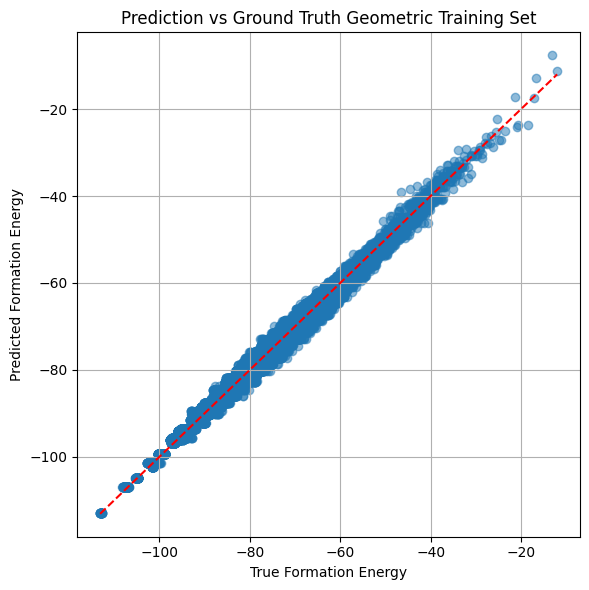

R² Score: 0.9893


In [49]:
# Geometric evaluation

y_true = []
y_pred = []
with torch.no_grad():
    geometricModel.load_state_dict(torch.load("gnn_model_geometric.pt"))
    geometricModel.eval()
    for data in graph_train_loader:
        data.to(device)
        output = geometricModel(data.x, data.edge_index, data.batch)
        y_true.append(data.y.cpu())
        y_pred.append(output.cpu())

y_true = torch.cat(y_true)
y_pred = torch.cat(y_pred).squeeze(-1)

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True Formation Energy")
plt.ylabel("Predicted Formation Energy")
plt.title("Prediction vs Ground Truth Geometric Training Set")
plt.grid(True)
plt.tight_layout()
plt.show()

r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}")

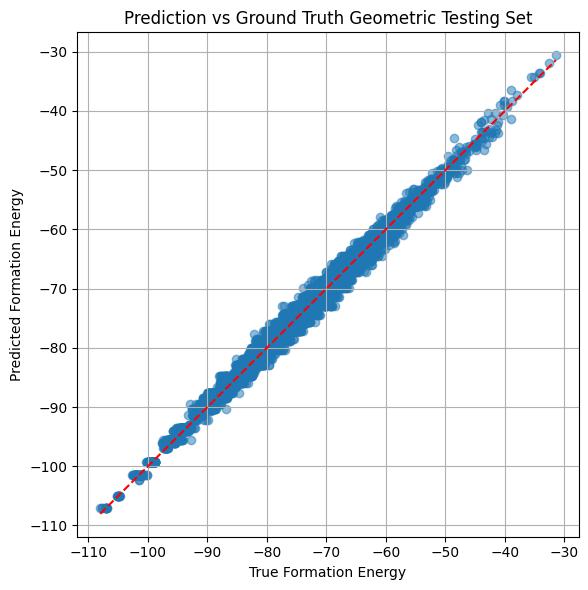

R² Score: 0.9896


In [50]:
y_true = []
y_pred = []
with torch.no_grad():
    geometricModel.load_state_dict(torch.load("gnn_model_geometric.pt"))
    geometricModel.eval()
    for data in graph_test_loader:
        data.to(device)
        output = geometricModel(data.x, data.edge_index, data.batch)
        y_true.append(data.y.cpu())
        y_pred.append(output.cpu())

y_true = torch.cat(y_true)
y_pred = torch.cat(y_pred).squeeze(-1)

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True Formation Energy")
plt.ylabel("Predicted Formation Energy")
plt.title("Prediction vs Ground Truth Geometric Testing Set")
plt.grid(True)
plt.tight_layout()
plt.show()

r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}")

## Task 2

In [20]:
subset_sizes = [100,300,1000,3000,10000]

In [21]:
# Training all SMILES Models
if train:    
    for size in subset_sizes:
            model = SmilesGNN(hidden_dim=128, node_dim=139, edge_dim=30).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
            loss = nn.MSELoss()
            indices = random.sample(range(len(train_smiles_data)), size)
            subset = Subset(train_smiles_data, indices)
            loader = DataLoader(subset, batch_size=32, shuffle=True)
            
            for epoch in range(1, 51):
                train_loss = smilesTrain(model, loader, loss, optimizer)
                test_loss = smilesTest(model, smiles_test_loader, loss)
                print(f"Size {size:06d} | Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
            torch.save(model.state_dict(), f'SMILES_model_subset_{size}.pth')

In [22]:
# Training all Geometric Models
def train_task2(subset_size):
    task2_gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
    task2_gnn = task2_gnn.to(device)
    optimizer = torch.optim.Adam(task2_gnn.parameters(), lr=0.0001)
    criterion = nn.MSELoss()
    num_epochs = 50
    min_val_loss = float('inf')
    
    subset_train_loader = DataLoader(train_graph_data[:subset_size], batch_size=128, shuffle=True)
    
    for epoch in range(num_epochs):
        
        geometricTrain(task2_gnn, subset_train_loader, optimizer, criterion, device)
        train_loss = geometricTest(task2_gnn, subset_train_loader, criterion, device)
        val_loss = geometricTest(task2_gnn, graph_val_loader, criterion, device)
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(task2_gnn.state_dict(), f'task2_gnn_geometric_{subset_size}.pt')
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

if train:
    for size in subset_sizes:
        print(f'Training with subset size: {size}')
        train_task2(size)

In [23]:
# Evaluate all models

smiles_r2s = []
smiles_mses = []
geo_r2s = []
geo_mses = []

# SMILES GNN
for size in subset_sizes:
    model = SmilesGNN(hidden_dim=128, node_dim=139, edge_dim=30).to(device)
    model.load_state_dict(torch.load(f'SMILES_model_subset_{size}.pth'))
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in smiles_test_loader:
            batch = batch.to(device)
            output = model(batch)
            y_true.extend(batch.y.cpu().numpy())
            y_pred.extend(output.cpu().numpy())
    
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    smiles_r2s.append(r2)
    smiles_mses.append(mse)
    print(f'SMILES GNN Size: {size:06d}, R2: {r2:.4f}, MSE: {mse:.4f}')

# Geometric GNN
task2_gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5).to(device)

for size in subset_sizes:
    task2_gnn.load_state_dict(torch.load(f'task2_gnn_geometric_{size}.pt'))
    y_true = []
    y_pred = []
    with torch.no_grad():
        task2_gnn.eval()
        for data in graph_test_loader:
            data.to(device)
            output = task2_gnn(data.x, data.edge_index, data.batch)
            y_true.append(data.y.cpu())
            y_pred.append(output.cpu())

    y_true = torch.cat(y_true)
    y_pred = torch.cat(y_pred).squeeze(-1)
    

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_pred, y_true)
    geo_r2s.append(r2)
    geo_mses.append(mse)
    print(f'Geometric GNN Size: {size:06d}, R2: {r2:.4f}, MSE: {mse:.4f}')

SMILES GNN Size: 000100, R2: 0.5645, MSE: 0.4397
SMILES GNN Size: 000300, R2: 0.7441, MSE: 0.2583
SMILES GNN Size: 001000, R2: 0.7856, MSE: 0.2165
SMILES GNN Size: 003000, R2: 0.8385, MSE: 0.1630
SMILES GNN Size: 010000, R2: 0.8581, MSE: 0.1432
Geometric GNN Size: 000100, R2: -13.5137, MSE: 1557.9175
Geometric GNN Size: 000300, R2: -2.3937, MSE: 364.2862
Geometric GNN Size: 001000, R2: 0.9066, MSE: 10.0307
Geometric GNN Size: 003000, R2: 0.9685, MSE: 3.3772
Geometric GNN Size: 010000, R2: 0.9809, MSE: 2.0528


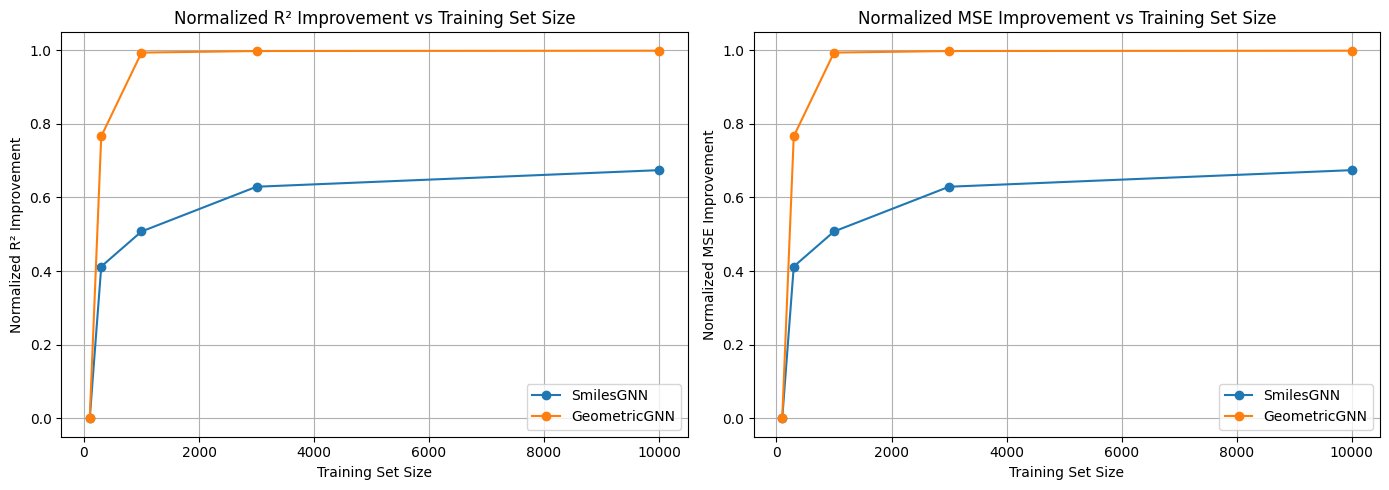

In [51]:
smiles_r2s = np.array(smiles_r2s)
smiles_mses = np.array(smiles_mses)
geo_r2s = np.array(geo_r2s)
geo_mses = np.array(geo_mses)
sizes = np.array(subset_sizes)

def normalized_improvement_r2(r2_scores):
    baseline = r2_scores[0]
    return (r2_scores - baseline) / (1 - baseline)

def normalized_improvement_mse(mse_scores):
    baseline = mse_scores[0]
    return (baseline - mse_scores) / baseline

smiles_r2_norm = normalized_improvement_r2(smiles_r2s)
geo_r2_norm = normalized_improvement_r2(geo_r2s)

smiles_mse_norm = normalized_improvement_mse(smiles_mses)
geo_mse_norm = normalized_improvement_mse(geo_mses)

fig, axs = plt.subplots(1, 2, figsize=(14,5))

axs[0].plot(sizes, smiles_r2_norm, marker='o', label='SmilesGNN')
axs[0].plot(sizes, geo_r2_norm, marker='o', label='GeometricGNN')
axs[0].set_xlabel('Training Set Size')
axs[0].set_ylabel('Normalized R² Improvement')
axs[0].set_title('Normalized R² Improvement vs Training Set Size')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(sizes, smiles_mse_norm, marker='o', label='SmilesGNN')
axs[1].plot(sizes, geo_mse_norm, marker='o', label='GeometricGNN')
axs[1].set_xlabel('Training Set Size')
axs[1].set_ylabel('Normalized MSE Improvement')
axs[1].set_title('Normalized MSE Improvement vs Training Set Size')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Task 3

In [25]:
! pip install deepchem transformers
from deepchem.feat.smiles_tokenizer import BasicSmilesTokenizer
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import math

2025-06-20 12:48:31.198906: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-20 12:48:31.229665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750416511.280419    3453 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750416511.297036    3453 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750416511.332790    3453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


In [26]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [27]:
canonicalize("COO"), canonicalize("O(C)O")

('COO', 'COO')

In [28]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")

(True, True, False)

In [29]:
tokenizer = BasicSmilesTokenizer()
counter = Counter()
for s in smiles_data:
  counter.update(tokenizer.tokenize(s))

vocab = {}
for k, v in counter.items():
  vocab[k] = len(vocab) + 1
vocab['<pad>'] = 0
vocab['<unk>'] = len(vocab)
vocab['<start>'] = len(vocab)
vocab['<end>'] = len(vocab)

In [30]:
def decoder_mask(size):
    mask = torch.triu(torch.ones(1, size, size), diagonal = 1).type(torch.int)
    return mask == 0

def tokenize_smiles(smiles_data):
  tokenizer = BasicSmilesTokenizer()
  tokenized_smiles = [['<start>']+tokenizer.tokenize(s)+['<end>'] for s in smiles_data]
  return tokenized_smiles

class SMILESDataset(Dataset):
  def __init__(self, smiles_data, vocab):
    self.vocab = vocab
    self.tokenized_smiles = tokenize_smiles(smiles_data)

  def __len__(self):
    return len(self.tokenized_smiles)

  def __getitem__(self, idx):
    int_smiles = [vocab.get(token, vocab['<unk>']) for token in self.tokenized_smiles[idx]]
    return int_smiles

def collate_fn(batch):
    smiles_list = []
    for _smiles in batch:
      smiles_list.append(torch.tensor(_smiles, dtype=torch.int64))

    smiles_batch = pad_sequence(smiles_list, batch_first=True, padding_value=vocab['<pad>'])
    dec_in = smiles_batch[:, :-1]  # decoder input, remove last token
    dec_out = smiles_batch[:, 1:]  # decoder output, remove first token

    enc_mask = (smiles_batch != vocab['<pad>']).unsqueeze(1).unsqueeze(1).int()
    dec_mask_in =  (dec_in != vocab['<pad>']).unsqueeze(1).unsqueeze(1).int()  # [batch_size, 1, 1, seq_len]
    dec_mask = decoder_mask(dec_in.size(-1)).unsqueeze(0)  # [1, seq_len, seq_len]

    mask = dec_mask_in & dec_mask

    return smiles_batch.to(device), dec_in.to(device), dec_out.to(device), mask.to(device)


In [31]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length, dropout):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        self.drop = nn.Dropout(dropout)

        pe[:, 0::2] = torch.sin(position / (10000 ** (torch.arange(0, d_model, 2) / d_model)))
        pe[:, 1::2] = torch.cos(position / (10000 ** (torch.arange(0, d_model, 2) / d_model)))

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]  # x shape: (batch_size, seq_length, d_model)
        out = self.drop(x)

        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model # input embedding size
        self.num_heads = num_heads # number of attention heads
        self.d_k = d_model // num_heads # attention embedding size

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
          attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output

    def split_heads(self, x):
        x = x.view(x.size(0), x.size(1), self.num_heads, self.d_k)
        x = x.transpose(1, 2)  # (batch_size, num_heads, seq_len, d_k)
        return x

    def combine_heads(self, x):
        x = x.transpose(1, 2)  # (batch_size, seq_len, num_heads, d_k)
        x = x.contiguous().view(x.size(0), x.size(1), self.d_model)  # (batch_size, seq_len, d_model)
        return x

    def forward(self, Q_in, K_in, V_in, mask=None):
        Q = self.W_q(Q_in)
        K = self.W_k(K_in)
        V = self.W_v(V_in)
        Q, K, V = self.split_heads(Q), self.split_heads(K), self.split_heads(V)
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output

class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [32]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderBlock, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, dec_mask):
        attn_output = self.self_attn(x, x, x, dec_mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length, dropout)
        self.layers = nn.ModuleList([DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.pred_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x, dec_mask):
        x = self.embedding(x)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, dec_mask)

        out = self.pred_layer(x)
        return out

In [33]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.decoder = Decoder(vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

    def forward(self, dec_in, dec_mask):
        out = self.decoder(dec_in, dec_mask)
        return out

In [34]:
train_data = [smiles_data[i] for i in train_idxes]
tokenized_train_data = tokenize_smiles(train_data)
MAX_SEQ_LENGTH = max([len(x) for x in tokenized_train_data])

In [35]:
BATCH_SIZE = 128
EPOCHS = 20
LR = 0.001

DROPOUT = 0.1
N_HEADS = 4
N_LAYERS = 4
HIDDEN_DIM = 64
FF_HIDDEN_DIM = 64

model = Transformer(vocab_size = len(vocab),
                          d_model = HIDDEN_DIM,
                          num_heads = N_HEADS,
                          num_layers = N_LAYERS,
                          d_ff = FF_HIDDEN_DIM,
                          max_seq_length = MAX_SEQ_LENGTH,
                          dropout=DROPOUT,
                          ).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])

In [36]:
def split_train_val_set(data_list, idx, vocab, val_ratio=0.1):
  """
  Construct training set and validation set.
  """
  dataset_size = len(idx)
  val_size = int(np.floor(val_ratio * dataset_size))
  shuffed_idx = np.random.permutation(idx)
  x_train = [data_list[i] for i in shuffed_idx[:-val_size]]
  x_val = [data_list[i] for i in shuffed_idx[-val_size:]]

  train_set = SMILESDataset(x_train, vocab)
  val_set = SMILESDataset(x_val, vocab)

  return train_set, val_set

In [37]:
def trainModel(model, dataloader, optimizer):

    epoch_loss = 0
    model.train()

    for i, (src, dec_in, dec_out, dec_mask) in enumerate(dataloader):
        optimizer.zero_grad()
        tgt_hat = model(dec_in, dec_mask).transpose(-1,-2)
        loss = criterion(tgt_hat, dec_out)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss/len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader):

    epoch_loss = 0
    model.eval()

    for i, (src, dec_in, dec_out, dec_mask) in enumerate(dataloader):
        tgt_hat = model(dec_in, dec_mask).transpose(-1,-2)
        loss = criterion(tgt_hat, dec_out)
        epoch_loss += loss.item()

    return epoch_loss/len(dataloader)

In [38]:
# Training loop
if train:
  for epoch in tqdm(range(EPOCHS)):
    train_loss, val_loss = 0, 0
    train_set, val_set = split_train_val_set(smiles_data, train_idxes, vocab)
    train_dl = DataLoader(train_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)
    val_dl = DataLoader(val_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)

    train_loss = trainModel(model, train_dl, optimizer)
    val_loss = evaluate(model, val_dl)

    # print the results
    print(
      f'EPOCH: {epoch+1:0>{len(str(EPOCHS))}}/{EPOCHS}',
      end=' '
    )
    print(f'LOSS: {train_loss:.4f}',end=' ')
    print(f'VAL-LOSS: {val_loss:.4f}',end='\n')

  torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
  }, 'transformer_decoder_checkpoint.pth')

In [39]:
def idx_to_smiles(id_list, vocab):
  special_idx = {vocab['<pad>'], vocab['<unk>'], vocab['<start>'], vocab['<end>']}
  end_loc = id_list.index(vocab['<end>']) if vocab['<end>'] in id_list else 0
  if end_loc > 0:
    id_list = id_list[:end_loc]
  smiles_idx = [idx for idx in id_list if idx not in special_idx]
  id_to_token = {v: k for k, v in vocab.items()}
  smiles_tokens = [id_to_token[i] for i in smiles_idx]
  smiles = ''.join(smiles_tokens)
  return smiles

In [ ]:
def top_k_sampling(logits, k):
    """
    Sample from the top k logits.
    """
    topk_logits, topk_idx = torch.topk(logits, k)
    probs = F.softmax(topk_logits, dim=-1)
    idx = torch.multinomial(probs, num_samples=1)
    return topk_idx.gather(1, idx)

@torch.no_grad()
def topk_decoder(model, dataloader, k=5):
  predictions = []
  for i, (src, dec_in, dec_out, dec_mask) in enumerate(dataloader):
    smiles = dec_in[:,[0]]  #  [batch_size, 1]
    smiles_len = 1

    while True:
      dec_mask = decoder_mask(smiles.size(1)).unsqueeze(0).to(device)
      out = model.decoder.forward(smiles, dec_mask)
      logits = out[:,-1,:]
      next = top_k_sampling(logits, k)
      smiles = torch.cat([smiles, next], dim=1)
      smiles_len += 1
      if smiles_len == MAX_SEQ_LENGTH:
        break

    for s in smiles.cpu():
      predictions.append(idx_to_smiles(s.tolist(), vocab))

  return predictions

In [41]:
checkpoint = torch.load('transformer_decoder_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [42]:
N_GENERATED_SMILES = 5000
input = ['' for _ in range(N_GENERATED_SMILES)]
input_set = SMILESDataset(input, vocab)
input_dl = DataLoader(input_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)
predictions = topk_decoder(model, input_dl)

In [43]:
canonical_predictions = [canonicalize(p) for p in predictions]
valid_mask = [is_valid_smiles(p) for p in canonical_predictions]
valid_smiles = [p for p, m in zip(canonical_predictions, valid_mask) if m]
print(f'validity: {len(valid_smiles) / len(canonical_predictions):.4f}')

unique_smiles = set(valid_smiles)
print(f'uniqueness {len(unique_smiles) / len(valid_smiles):.4f}')

train_smiles = [smiles_data[i] for i in train_idxes]
is_in_trainset = [s in train_smiles for s in unique_smiles]
print(f'novelty: {1 - sum(is_in_trainset) / len(unique_smiles):.4f}')

validity: 0.9180
uniqueness 0.9492
novelty: 0.5970
